# Основи нейронних мереж

## Вступ до нейронних мереж

### Одношаровий персептрон і завдання класифікації

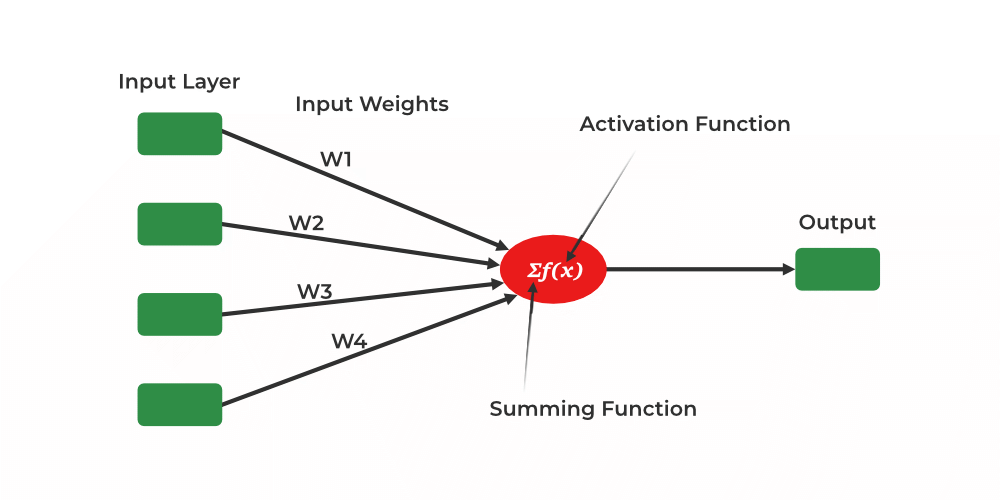

### Багатошаровий персептрон (MLP)

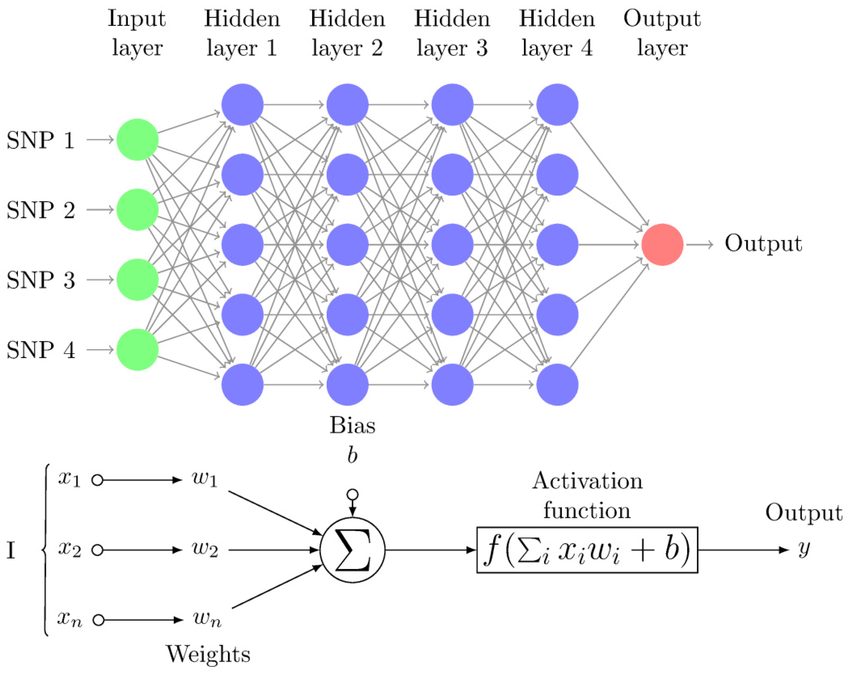

### Приклад та реалізація багатошарового персептрона

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(20,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')                  
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=30, batch_size=32,
          validation_data=(X_val, y_val))

predictions = model.predict(X_test)

ModuleNotFoundError: No module named 'tensorflow'

### Алгоритм прямого поширення

Прохід даних від входу до виходу, коли ми обчислюємо прогноз мережі, ще не змінюючи ваги

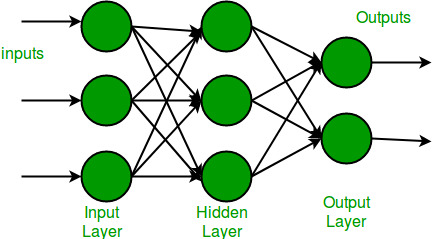

### Алгоритм зворотного поширення помилки

Backpropagation — це спосіб автоматично знайти, як змінити кожну вагу, щоб зменшити помилку.

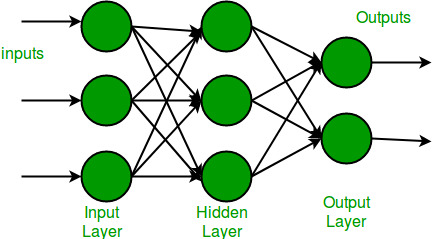

### Поняття оптимізації

Процес пошуку найкращих значень параметрів (ваг і зміщень), щоб мережа робила якомога менше помилок на тренувальних даних.


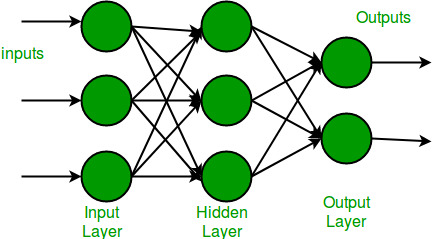

### Алгоритми оптимізації

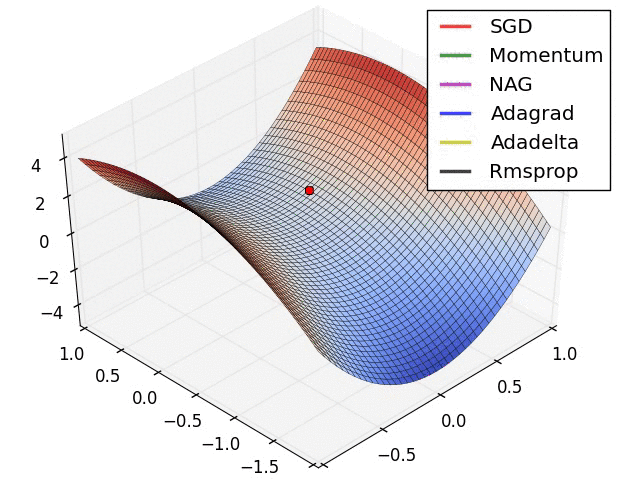

### Знайомство з бібліотекою PyTorch

PyTorch — це один із найпопулярніших фреймворків для побудови та навчання нейронних мереж.

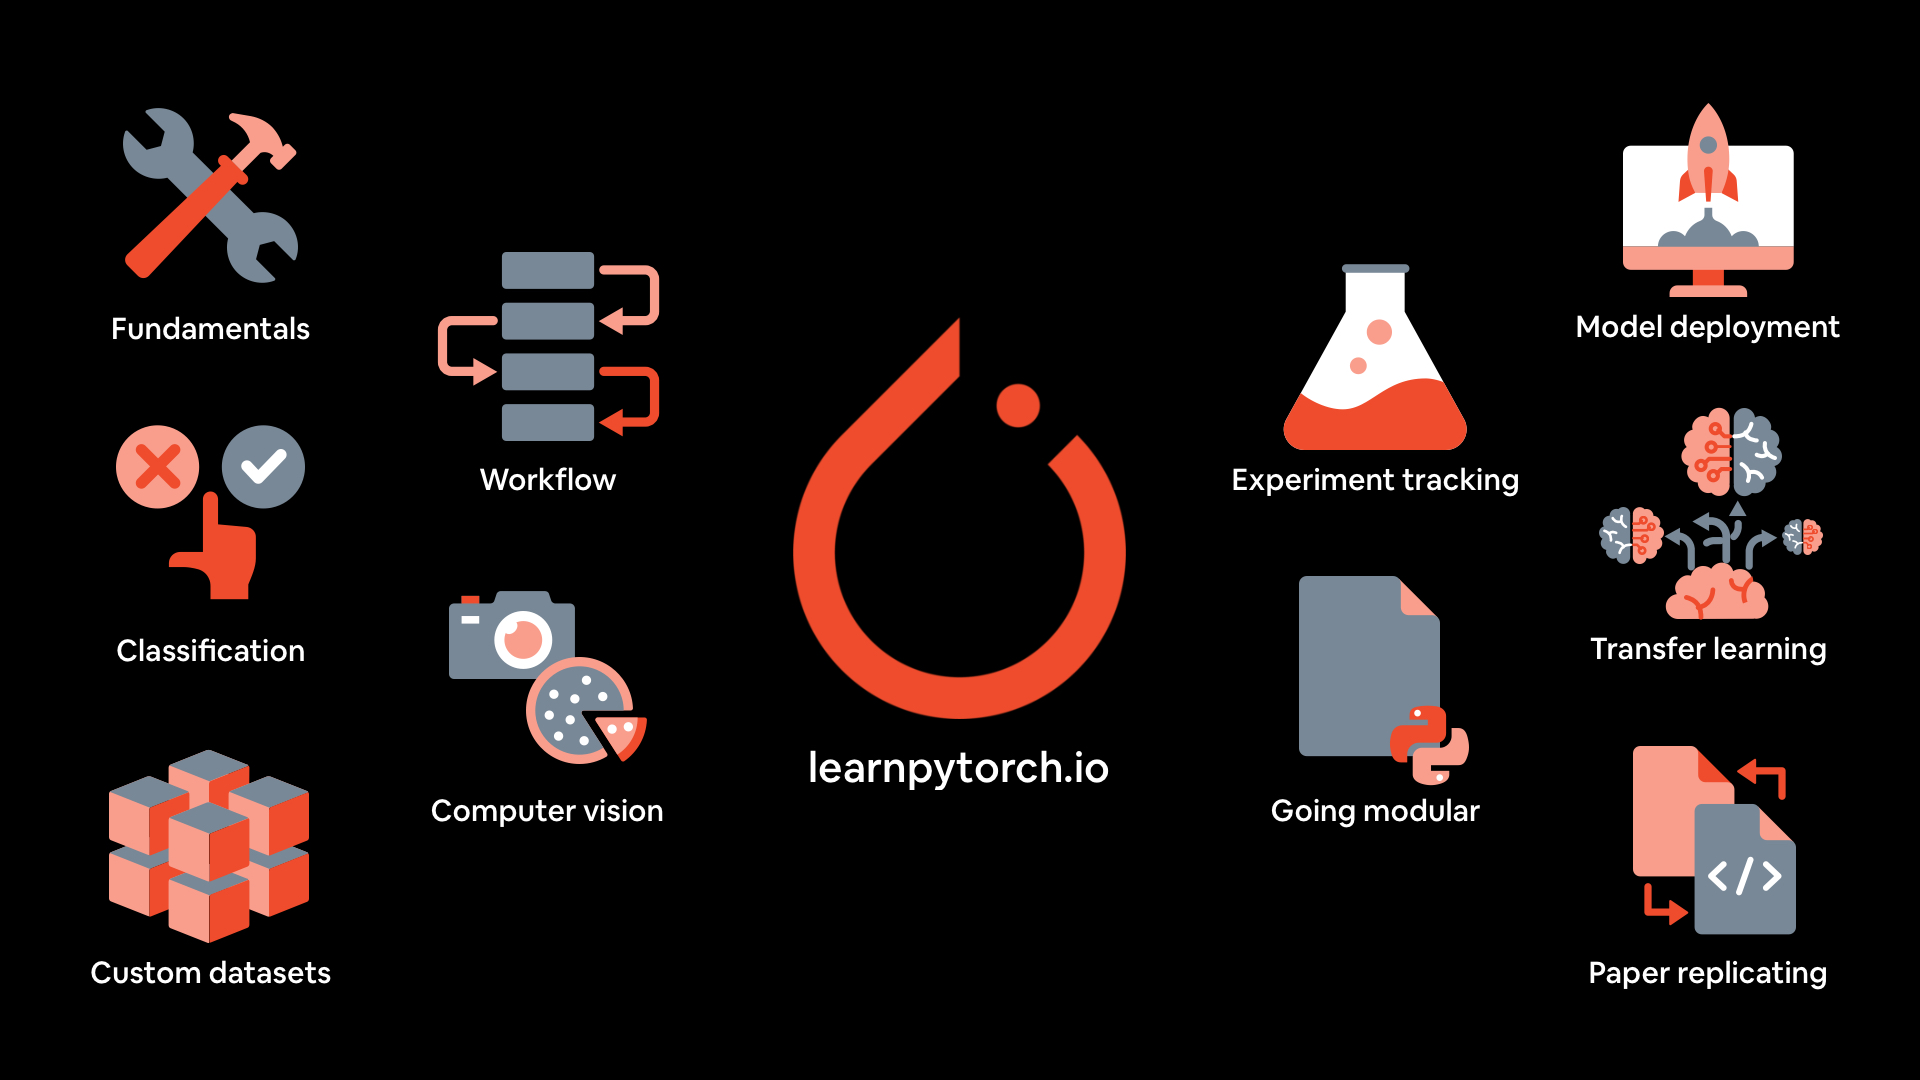

### Поняття тензора

Тензор — це головна структура даних у PyTorch.

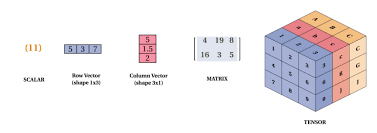

### Поняття графа обчислень

Граф обчислень — це схема (мережа) операцій, яка описує, як із початкових тензорів отримати кінцевий результат.

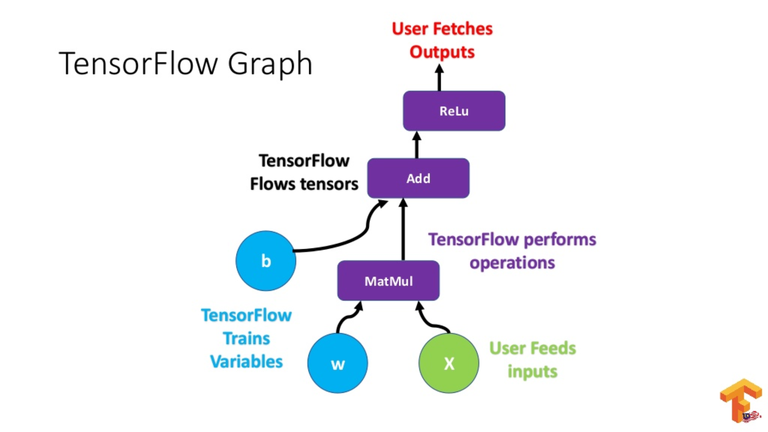

### Модуль для побудови нейронних мереж

У PyTorch головним інструментом для створення моделей є torch.nn.

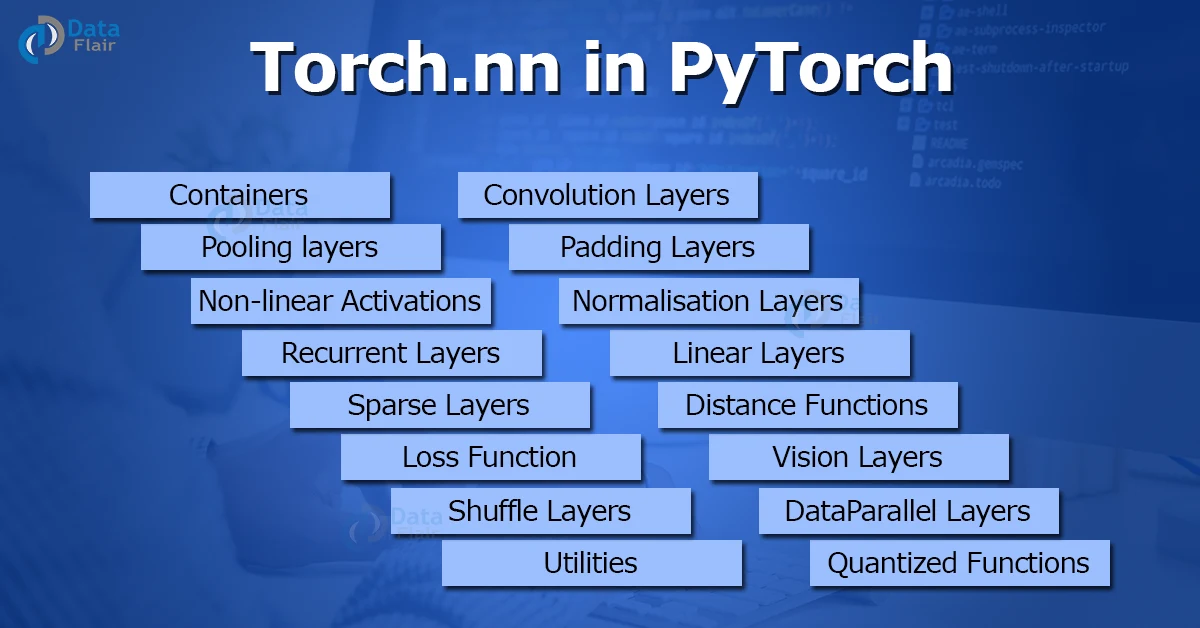

###  Класи оптимізаторів

Оптимізатор у PyTorch — це об’єкт, який знає як оновлювати параметри моделі після обчислення градієнтів під час навчання.

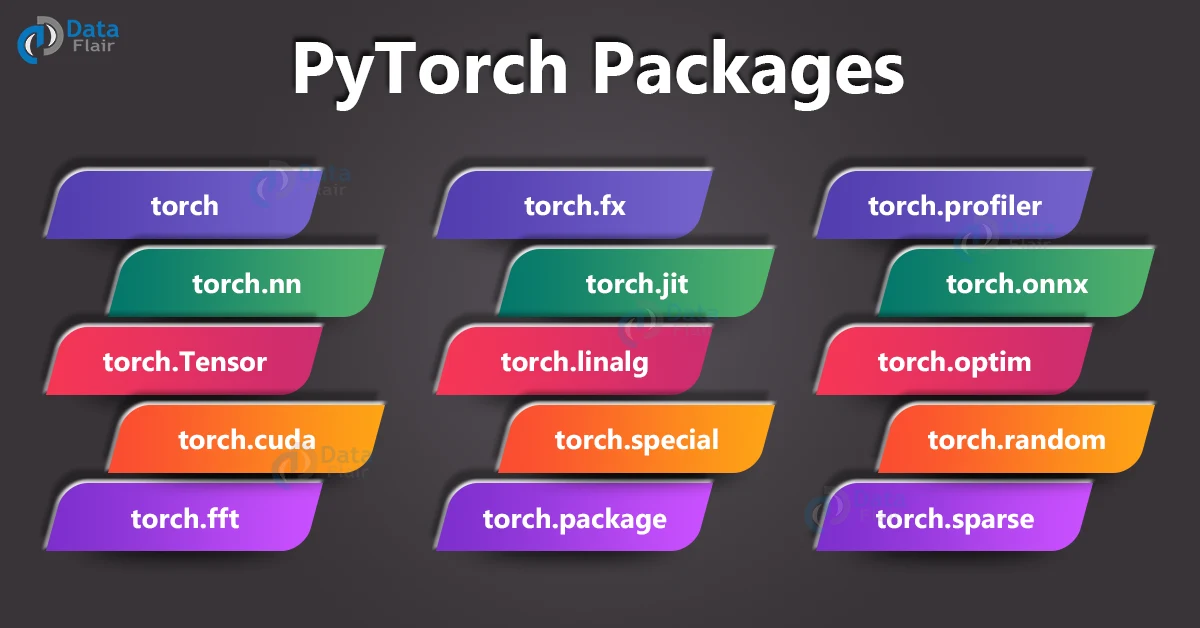

### Класи для функції втрат

Функція втрат (loss function) — це міра, наскільки передбачення моделі відрізняються від правильних значень.

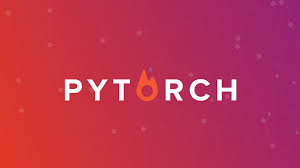

### Класи для тренування

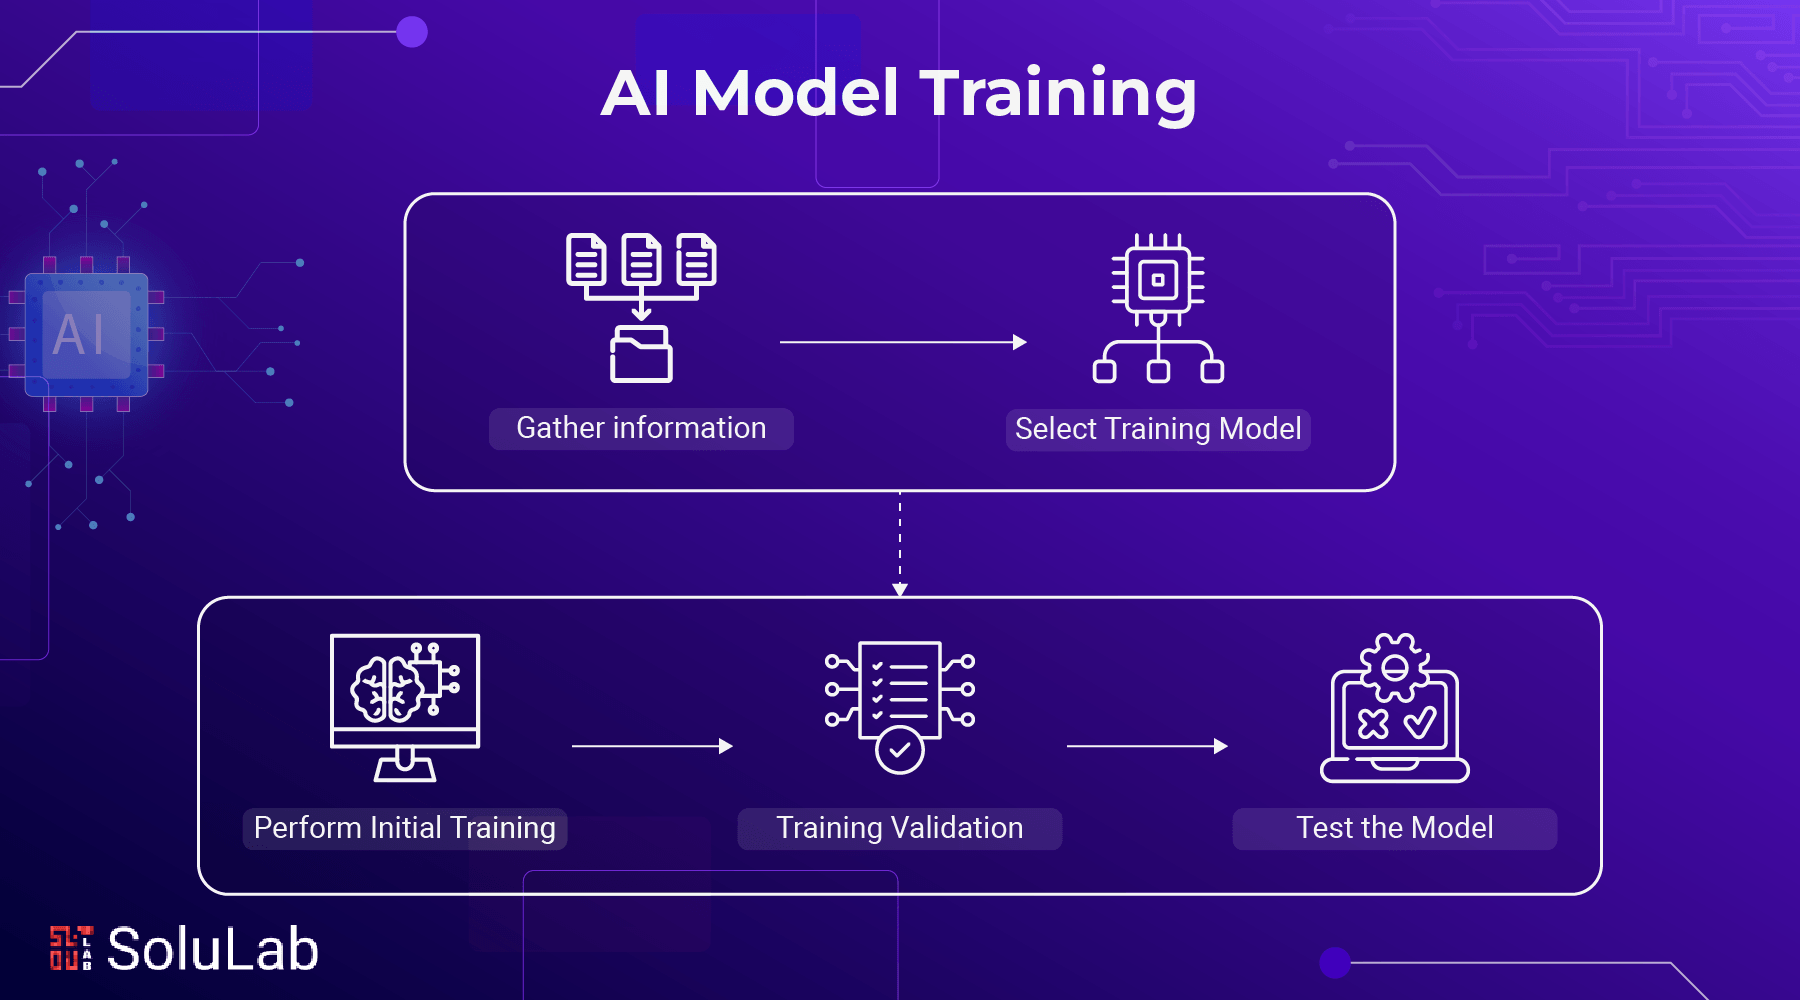

### Dropout регуляризація

Dropout — це популярний метод регуляризації нейронних мереж, який допомагає уникати перенавчання (overfitting).

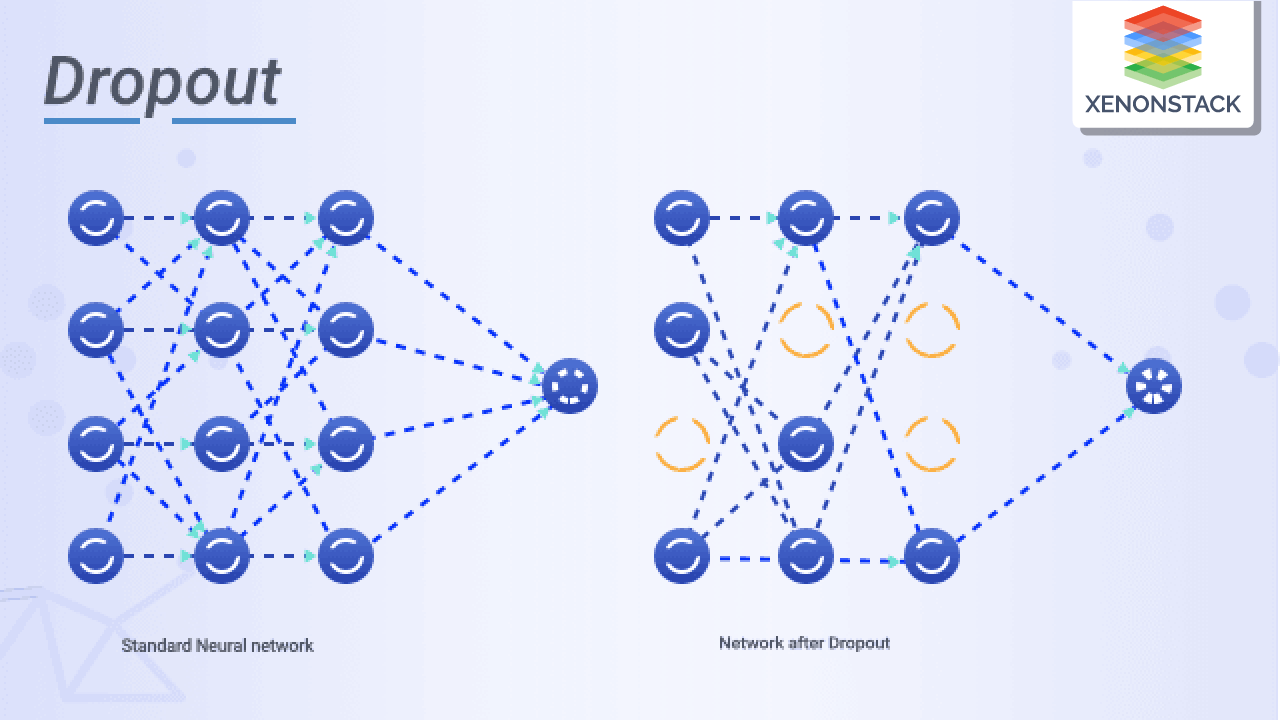

### Приклад побудови нейронної мережі засобами PyTorch

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [16]:
df = pd.read_csv('Telco-Customer-Churn.csv')

df = pd.get_dummies(df, drop_first=True)

scaler = StandardScaler()
y = df['Churn_Yes']
X = df.drop(columns=['Churn_Yes'])

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [17]:
class ChurnNN(nn.Module):
    def __init__(self, input_size):
        super(ChurnNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

model = ChurnNN(input_size=X_train.shape[1])

In [18]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.3285
Epoch [20/100], Loss: 0.0751
Epoch [30/100], Loss: 0.0116
Epoch [40/100], Loss: 0.0027
Epoch [50/100], Loss: 0.0011
Epoch [60/100], Loss: 0.0006
Epoch [70/100], Loss: 0.0005
Epoch [80/100], Loss: 0.0004
Epoch [90/100], Loss: 0.0003
Epoch [100/100], Loss: 0.0003


In [20]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_classes = (y_pred > 0.5).float()
    accuracy = accuracy_score(y_test_tensor, y_pred_classes)
    print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 73.88%
